# Extending · Add a new wave equation

This notebook walks from a blank file to a working second-order scalar
wave equation `MyScalar`, plugs it into `PropTorch`, runs a forward
pass, and verifies a clean P-wave ring propagating at the prescribed
velocity.

The static reference — the full interface contract, the
`CUDALayoutSpec` field table, and the `impl="c"` path — lives in the
[Extending guide](../../user-guide/extending/). This notebook is the
runnable companion: code you can copy, modify, and `Run All` against
your own physics.


## What we will build

- Subclass `SecondOrderEquation` with a `vp` model and a single `h1`
  pressure-like field.
- Inspect the equation's structured metadata (`MODEL_SPECS`,
  `FIELD_SPECS`, `available_source_fields`, defaults).
- Wire it into `PropTorch(impl="eager")` and run a short forward.
- Plot wavefield snapshots and a receiver trace — verify the P-wave
  ring expands at the expected 2000 m/s.

`impl="c"` (compiled CUDA kernels) requires `_C()`, a `CUDALayoutSpec`,
and a `module.cpp` registration — see the
[Extending guide](../../user-guide/extending/#adding-the-compiled-cuda-hook)
for the spec.


## 1. Define `MyScalar`

Four things the equation must provide for the eager path:

| Item | Type | What it does |
|---|---|---|
| `MODEL_SPECS` | class attr | model tensor order + units / aliases |
| `FIELD_SPECS` | class attr | wavefield order + source/receiver flags |
| `default_pml_type` | class attr | `"cpmlr"`, `"cpmls"`, or `"spml"` |
| `func(wavefields, models, dt, h, b, **kwargs)` | method | one time step |

Everything else — `wavefields` / `models` / `field_specs` / `model_specs`
properties, PML profile initialisation, separable Laplace kernels, the
propagator-side plumbing — is inherited from `SecondOrderEquation` and
derived from `FIELD_SPECS` / `MODEL_SPECS` automatically.


In [1]:
from sweep.equations.base import SecondOrderEquation
from sweep.equations.fields import FieldSpec, ModelSpec


class MyScalar(SecondOrderEquation):
    """Toy second-order scalar wave equation: u_tt = vp**2 * Laplace(u).

    Deliberately minimal — no PML term inside `func`, no LSRTM
    reflectivity, no anisotropy. The PML auxiliary buffer `b` is still
    constructed by the propagator (because `default_pml_type` is set)
    but unused here; the simulation stops before the wave reaches the
    boundary.
    """

    MODEL_SPECS = (
        ModelSpec("vp", description="P-wave velocity.", unit="m/s"),
    )
    FIELD_SPECS = (
        FieldSpec(
            "h1",
            description="Primary scalar wavefield.",
            supports_source=True,
            supports_receiver=True,
        ),
        FieldSpec(
            "h2",
            description="Previous-step scalar wavefield.",
            internal=True,
        ),
    )
    default_pml_type = "cpmlr"

    def __init__(self, spatial_order=4, device="cpu", backend="torch", dim=2):
        super().__init__(spatial_order, device, backend, dim=dim)
        self.init_laplace(ltype="1dsep", backend=backend)

    def func(self, wavefields, models, dt, h, b, **kwargs):
        u_now, u_pre = wavefields
        (vp,) = models
        hz, hx = self._spacings_2d(h)
        lap_z, lap_x = self.laplace1d_sep(u_now, self.laplace_kernels, hz, hx)
        u_next = 2 * u_now - u_pre + (vp * dt) ** 2 * (lap_z + lap_x)
        return u_next, u_now


## 2. Inspect the structured metadata

The same introspection that ships with every built-in equation works
out of the box. `WaveEquation` derives the `wavefields` / `models` /
`field_specs` / `model_specs` properties from the class-level
`FIELD_SPECS` / `MODEL_SPECS` tables, so we did not have to write any
of them by hand.


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eq = MyScalar(spatial_order=4, device=device, backend="torch")

print("class_name      :", type(eq).__name__)
print("models          :", eq.models)
print("wavefields      :", eq.wavefields)
print("default_pml_type:", eq.default_pml_type)
print("defaults src/rec:", eq.default_source_fields, "/", eq.default_receiver_fields)
print()
print("available source fields:")
for s in eq.available_source_fields():
    print(f"  - {s.name}: {s.description}")
print("available receiver fields:")
for s in eq.available_receiver_fields():
    print(f"  - {s.name}: {s.description}")


class_name      : MyScalar
models          : ['vp']
wavefields      : ['h1', 'h2']
default_pml_type: cpmlr
defaults src/rec: ['h1'] / ['h1']

available source fields:
  - h1: Primary scalar wavefield.
available receiver fields:
  - h1: Primary scalar wavefield.


## 3. Wire it into `PropTorch` and run a forward

`MyScalar` is now indistinguishable from any shipped equation as far
as `PropTorch` is concerned: it carries the same metadata, the same
`func` signature, and the same `default_pml_type` contract.

Uniform `vp = 2000 m/s` model, 15 Hz Ricker at the centre, one
receiver 200 m to the right. We deliberately stop before the wave
reaches the (un-attenuated) boundary, so the absence of a PML term in
`func` is invisible in the result.

We pass `eager_options=EagerOptions(use_compile=False)`. The eager
backend wraps `func` in `torch.compile` by default for speed —
disabling it keeps this minimal demo free of inductor warmup and
focuses the output on the equation interface. In a production FWI
loop, leave `use_compile` at its default `True`.


In [3]:
import numpy as np
from sweep.propagator.torch import PropTorch
from sweep.propagator.options import EagerOptions
from sweep.signal import ricker

shape   = (160, 160)
dh, dt  = 10.0, 0.001
nt      = 250
freq, delay = 15.0, 0.06

vp = torch.full(shape, 2000.0, dtype=torch.float32, device=device)

src_iz, src_ix = shape[0] // 2, shape[1] // 2
sources   = np.array([[src_ix, src_iz]], dtype=np.int64)             # (nshots, (x, z))
receivers = np.array([[[src_ix + 20, src_iz]]], dtype=np.int64)      # (nshots, nrec, (x, z))

t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)

solver = PropTorch(
    eq, shape=shape, dh=dh, dt=dt, nt=nt,
    impl="eager", use_ckpt=False,
    eager_options=EagerOptions(use_compile=False),
)

with torch.no_grad():
    rec, snaps = solver(
        wavelet, sources, receivers,
        models=[vp], return_wavefield=True,
        snapshot_times=[80, 160, 240],
    )

print("receiver data shape:", tuple(rec.shape))    # (B, nt, nrec, n_rec_fields)
print("snapshot shape     :", tuple(snaps.shape))  # (nsnap, n_wavefields, B, ?, nz_pad, nx_pad)
print("max |snapshot|     :", snaps.abs().max().item())


receiver data shape: (1, 250, 1, 1)
snapshot shape     : (3, 2, 1, 1, 260, 260)
max |snapshot|     : 4.412405014038086


## 4. Wavefield snapshots and receiver trace

Three snapshots at `t = 0.08 / 0.16 / 0.24 s`. With `vp = 2000 m/s`
the P-wave ring should expand to ≈160 / 320 / 480 m — comfortably
inside the 1600 m physical grid. The fourth panel is the receiver
trace, with the geometric arrival predicted by `t = offset / vp =
200 m / 2000 m/s = 0.10 s`.


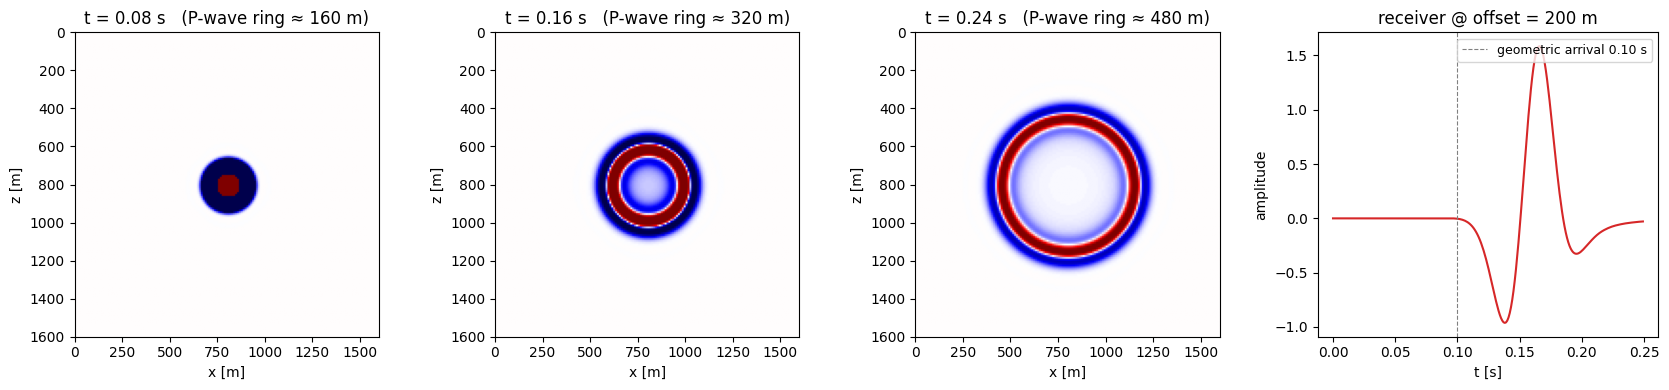

In [4]:
import matplotlib.pyplot as plt

snaps_np = snaps.detach().cpu().numpy()
# layout: (nsnap, n_wavefields, B, ?, nz_pad, nx_pad). Take h1 (idx 0), B=0, squeeze.
h1_snaps = snaps_np[:, 0, 0, 0]   # (nsnap, nz_pad, nx_pad)

# Crop the PML halo on each side so the wave physics is what we plot.
pml = (h1_snaps.shape[-1] - shape[1]) // 2
h1_interior = h1_snaps[:, pml:pml + shape[0], pml:pml + shape[1]]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
snap_times = [80, 160, 240]
for i, ax in enumerate(axes[:3]):
    frame = h1_interior[i]
    lo, hi = np.percentile(frame, [2, 98])
    clim = max(abs(lo), abs(hi))
    ax.imshow(frame, cmap="seismic", vmin=-clim, vmax=clim,
              extent=[0, shape[1] * dh, shape[0] * dh, 0])
    ax.set_title(f"t = {snap_times[i] * dt:.2f} s   (P-wave ring ≈ {snap_times[i] * dt * 2000:.0f} m)")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("z [m]")

rec_trace = rec.detach().cpu().numpy()[0, :, 0, 0]   # (nt,)
axes[3].plot(t, rec_trace, color="C3")
axes[3].axvline(0.10, ls="--", color="gray", lw=0.8, label="geometric arrival 0.10 s")
axes[3].set_title("receiver @ offset = 200 m")
axes[3].set_xlabel("t [s]")
axes[3].set_ylabel("amplitude")
axes[3].legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()


The receiver trace peaks slightly after `t = 0.10 s` because the
Ricker has a 0.06 s delay built in — the source emits at `t ≈ 0.06 s`,
the first-arrival is then at `0.06 + 0.10 = 0.16 s`. Both the
snapshot radii and the receiver arrival match the prescribed
velocity, so the equation is wired up correctly.


## 5. Making it discoverable

`MyScalar` lives in this notebook's namespace. To make it appear in
`sweep list equations`, in `sweep.equations._equation_classes()`, and
in `torch_binding_supported_equations()` (once `_C()` is added), drop
the class into `src/sweep/equations/my_scalar.py` and add **one** line:

```python
# src/sweep/equations/__init__.py
from .my_scalar import MyScalar
```

No registry edit, no factory dict, no whitelist. SWEEP's discovery
reflects over the `sweep.equations` namespace, so importing the class
is the entire registration.


## What's next

- **Compiled CUDA path (`impl="c"`)** — add `_C()` returning the
  forward + 4 backward variants and a `cuda_layout` property; then a
  five-line entry in `src/sweep/csrc/bindings/module.cpp`. The
  `CUDALayoutSpec` field table is in the
  [Extending guide](../../user-guide/extending/#cuda_layout-fields),
  and [`Acoustic`](https://github.com/DeepWave-KAUST/sweep/blob/dev/src/sweep/equations/acoustic.py)
  is the smallest end-to-end reference (eager + CUDA hook in one
  file).
- **Cross-cutting features** (irregular topography APM, RTM, new
  memory modes) require propagator-side changes and sit outside the
  "add an equation" path — see the
  [Extending guide](../../user-guide/extending/#out-of-scope-here).
